Name: Kashish Gupta

Enrollment Number: 10101042025

College: IGDTUW

In [ ]:
#1
import pandas as pd

# Load dataset
df = pd.read_csv("Loan prediction.csv")

# 1. Display first 10 records
print("First 10 Records")
print(df.head(10))

# 2. Features and target variable
print("\nFeatures:")
print(df.columns[:-1])

print("\nTarget Variable:")
print(df.columns[-1])

# 3. Number of records and attributes
print("\nShape of Dataset:")
print(df.shape)

print("Rows =", df.shape[0])
print("Columns =", df.shape[1])

# 4. Missing values
print("\nMissing Values")
print(df.isnull().sum())

# 5. Statistical summary
print("\nStatistical Summary")
print(df.describe())

First 10 Records
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   
5  LP001011   Male     Yes          2      Graduate           Yes   
6  LP001013   Male     Yes          0  Not Graduate            No   
7  LP001014   Male     Yes         3+      Graduate            No   
8  LP001018   Male     Yes          2      Graduate            No   
9  LP001020   Male     Yes          1      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2         

In [ ]:
#2
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Make a copy
data = df.copy()

# Fill missing categorical values
categorical = data.select_dtypes(include="object").columns

for col in categorical:
    data[col] = data[col].fillna(data[col].mode()[0])

# Fill missing numerical values
numerical = data.select_dtypes(include=["int64","float64"]).columns

for col in numerical:
    data[col] = data[col].fillna(data[col].median())

# Convert categorical variables into numbers
le = LabelEncoder()

for col in categorical:
    data[col] = le.fit_transform(data[col])

# Feature matrix and target variable
X = data.drop("Loan_Status", axis=1)
y = data["Loan_Status"]

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (614, 12)
Target Shape: (614,)


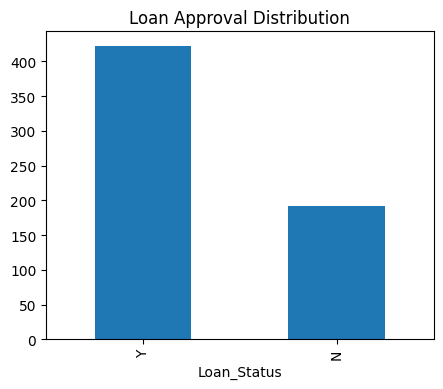

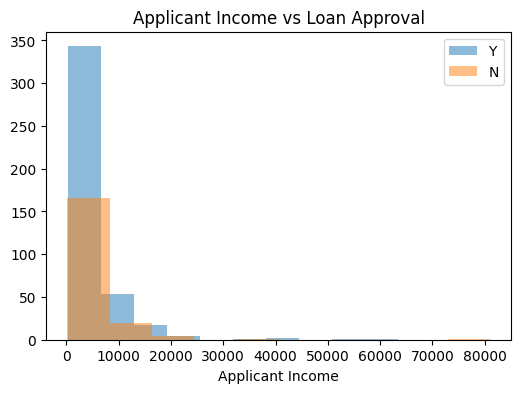

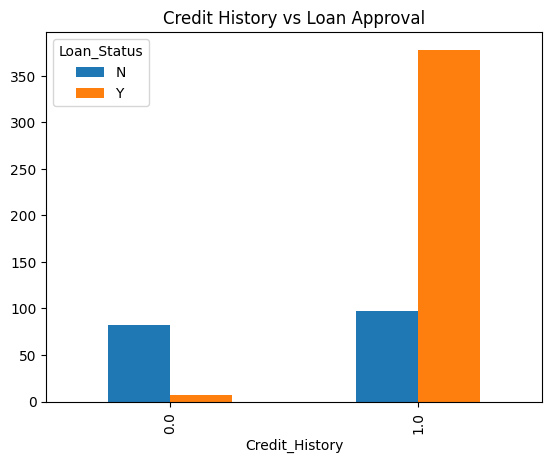

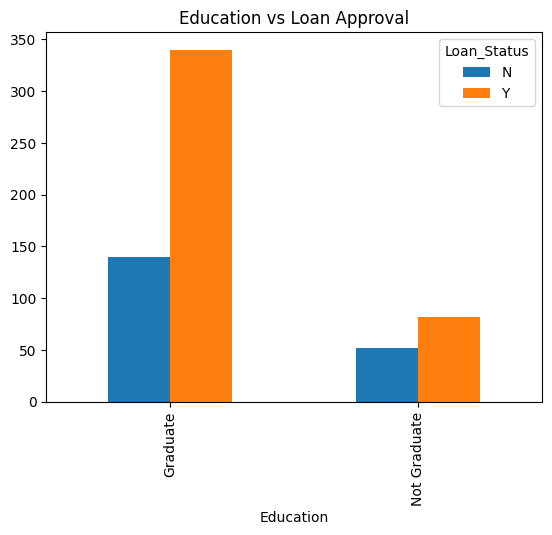

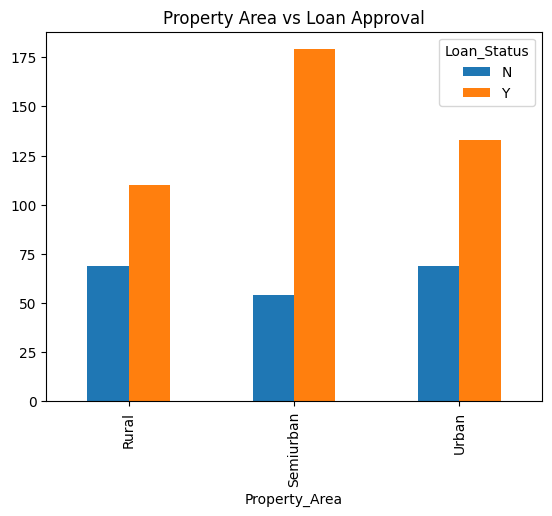

EDA Completed


In [ ]:
#3
import matplotlib.pyplot as plt

# 1. Loan Approval Distribution
plt.figure(figsize=(5,4))
df["Loan_Status"].value_counts().plot(kind="bar")
plt.title("Loan Approval Distribution")
plt.show()

# 2. Applicant Income vs Loan Approval
plt.figure(figsize=(6,4))
for status in df["Loan_Status"].unique():
    plt.hist(df[df["Loan_Status"]==status]["ApplicantIncome"],
             alpha=0.5,
             label=status)

plt.legend()
plt.title("Applicant Income vs Loan Approval")
plt.xlabel("Applicant Income")
plt.show()

# 3. Credit History vs Loan Approval
credit = pd.crosstab(df["Credit_History"],df["Loan_Status"])
credit.plot(kind="bar")
plt.title("Credit History vs Loan Approval")
plt.show()

# 4. Education vs Loan Approval
education = pd.crosstab(df["Education"],df["Loan_Status"])
education.plot(kind="bar")
plt.title("Education vs Loan Approval")
plt.show()

# 5. Property Area vs Loan Approval
property_area = pd.crosstab(df["Property_Area"],df["Loan_Status"])
property_area.plot(kind="bar")
plt.title("Property Area vs Loan Approval")
plt.show()

print("EDA Completed")

In [ ]:
print("1. Most influential feature: Credit_History")

print("\n2. Patterns Observed:")
print("- Applicants with good credit history are mostly approved.")
print("- Higher applicant income generally increases approval chances.")
print("- Graduates receive more approvals than non-graduates.")
print("- Semiurban areas have comparatively higher approvals.")
print("- Loan approvals are more than loan rejections.")


1. Most influential feature: Credit_History

2. Patterns Observed:
- Applicants with good credit history are mostly approved.
- Higher applicant income generally increases approval chances.
- Graduates receive more approvals than non-graduates.
- Semiurban areas have comparatively higher approvals.
- Loan approvals are more than loan rejections.


In [ ]:
#4
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Models
lr = LogisticRegression()
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test,pred)
    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred)
    f1 = f1_score(y_test,pred)

    results.append([name,accuracy,precision,recall,f1])

comparison = pd.DataFrame(results,
                          columns=["Model",
                                   "Accuracy",
                                   "Precision",
                                   "Recall",
                                   "F1 Score"])

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.861789   0.840000  0.988235  0.908108
1        Decision Tree  0.764228   0.825581  0.835294  0.830409
2        Random Forest  0.813008   0.822917  0.929412  0.872928


In [ ]:
#5
best = comparison.sort_values(by="Accuracy",ascending=False)

print("Best Performing Model")
print(best.iloc[0])

print("\nJustification:")
print("The model with the highest Accuracy and F1 Score is considered the best.")

print("\nStrengths and Limitations")

print("\nLogistic Regression")
print("Strength: Fast and simple.")
print("Limitation: Cannot capture complex relationships.")

print("\nDecision Tree")
print("Strength: Easy to interpret.")
print("Limitation: Can overfit.")

print("\nRandom Forest")
print("Strength: High accuracy and less overfitting.")
print("Limitation: More computationally expensive.")

Best Performing Model
Model        Logistic Regression
Accuracy                0.861789
Precision                   0.84
Recall                  0.988235
F1 Score                0.908108
Name: 0, dtype: object

Justification:
The model with the highest Accuracy and F1 Score is considered the best.

Strengths and Limitations

Logistic Regression
Strength: Fast and simple.
Limitation: Cannot capture complex relationships.

Decision Tree
Strength: Easy to interpret.
Limitation: Can overfit.

Random Forest
Strength: High accuracy and less overfitting.
Limitation: More computationally expensive.


In [ ]:
#6
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
import numpy as np

# Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Stratified 5-Fold Cross Validation Results\n")

for name, model in models.items():

    scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")

    print(name)
    print("Accuracy for each fold:", scores)
    print("Mean Accuracy:", np.mean(scores))
    print("Standard Deviation:", np.std(scores))
    print("-"*50)

print("\nComparison:")
print("Comparing the above mean accuracies with the train-test accuracies obtained in Question 4.")

Stratified 5-Fold Cross Validation Results

Logistic Regression
Accuracy for each fold: [0.81300813 0.82113821 0.80487805 0.75609756 0.82786885]
Mean Accuracy: 0.8045981607357058
Standard Deviation: 0.025448821062939588
--------------------------------------------------
Decision Tree
Accuracy for each fold: [0.73170732 0.72357724 0.69105691 0.6504065  0.7295082 ]
Mean Accuracy: 0.7052512328401972
Standard Deviation: 0.031092089451490786
--------------------------------------------------
Random Forest
Accuracy for each fold: [0.78861789 0.81300813 0.79674797 0.7398374  0.78688525]
Mean Accuracy: 0.7850193256030921
Standard Deviation: 0.024408080880327237
--------------------------------------------------

Comparison:
Comparing the above mean accuracies with the train-test accuracies obtained in Question 4.


In [ ]:
print("Answer 1:")
print("Stratified K-Fold is preferred because it keeps the same proportion of approved and rejected loans in every fold.")

print("\nAnswer 2:")
print("The model with the highest mean accuracy and lowest standard deviation is the most consistent.")

Answer 1:
Stratified K-Fold is preferred because it keeps the same proportion of approved and rejected loans in every fold.

Answer 2:
The model with the highest mean accuracy and lowest standard deviation is the most consistent.


In [ ]:
#7
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(grid.best_score_)

# Best model
best_rf = grid.best_estimator_

# Test Accuracy
pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print("\nPerformance After Tuning")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross Validation Score:
0.8004122861265719

Performance After Tuning
Accuracy : 0.8455284552845529
Precision: 0.8235294117647058
Recall   : 0.9882352941176471
F1 Score : 0.8983957219251337


In [ ]:
print("Before Tuning")
rf.fit(X_train, y_train)

before = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, before))
print("Precision:", precision_score(y_test, before))
print("Recall   :", recall_score(y_test, before))
print("F1 Score :", f1_score(y_test, before))

print("\nAfter Tuning")

after = best_rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, after))
print("Precision:", precision_score(y_test, after))
print("Recall   :", recall_score(y_test, after))
print("F1 Score :", f1_score(y_test, after))

Before Tuning
Accuracy : 0.8130081300813008
Precision: 0.8229166666666666
Recall   : 0.9294117647058824
F1 Score : 0.8729281767955801

After Tuning
Accuracy : 0.8455284552845529
Precision: 0.8235294117647058
Recall   : 0.9882352941176471
F1 Score : 0.8983957219251337


In [ ]:
#8
depths = [2, 5, 15]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append([depth, train_acc, test_acc])

bias_variance = pd.DataFrame(
    results,
    columns=["Max Depth", "Training Accuracy", "Testing Accuracy"]
)

print(bias_variance)

   Max Depth  Training Accuracy  Testing Accuracy
0          2           0.804481          0.853659
1          5           0.824847          0.837398
2         15           1.000000          0.764228


In [ ]:
print("Underfitting Model:")
print("max_depth = 2")

print("\nOverfitting Model:")
print("max_depth = 15")

print("\nBest Bias-Variance Balance:")
print("Usually max_depth = 5, because it balances training and testing accuracy.")

Underfitting Model:
max_depth = 2

Overfitting Model:
max_depth = 15

Best Bias-Variance Balance:
Usually max_depth = 5, because it balances training and testing accuracy.


In [ ]:
#END